In [1]:
# uncomment the line below if you need to install ipywidgets
# ! pip install ipywidgets
from ipywidgets import interact, ToggleButtons
import numpy as np
import matplotlib.pyplot as plt

Activation functions

In [6]:
def linear(z):
    return z
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def relu(z):
    return np.maximum(0, z)

In [12]:
x = np.linspace(0,1,1000)

@interact(w=(0.1,100.0,0.1),
          b=(-20.0,20.0,0.1))

def neuron(w=10, b=-5):
    # Uncomment to use different activation functions and notice the difference
    
    # y = linear(w*x+b)
    y = relu(w*x + b)
    #y = sigmoid(w*x + b)

    plt.figure(figsize=(6,4))
    plt.plot(x, y)
    plt.ylim(-0.05,1.05)
    plt.xlabel("x")
    plt.ylabel("Neuron output")
    plt.title(f"w={w:.1f}, b={b:.1f}")
    plt.show()

interactive(children=(FloatSlider(value=10.0, description='w', min=0.1), FloatSlider(value=-5.0, description='…

Instead of using a bias b, it might be easier to understand what is going on using a step parameter s, where s = -b/w.

# Q: Which parameter (s or w) controls where the activation turns on? Which one controls how sharp the transition is?

In [23]:
x = np.linspace(0,1,1000)

@interact(w=(0.1,100.0,0.1),
          b=(-20.0,20.0,0.1))

def neuron(w=10, s=0.5):

    z = w * (x - s)

    #y = linear(z)
    y = relu(z)
    #y = sigmoid(z)

    plt.figure(figsize=(6,4))
    plt.plot(x, y)
    plt.ylim(-0.05,1.05)
    plt.xlabel("x")
    plt.ylabel("Neuron output")
    plt.title(f"w={w:.1f},  step={s:.2f}")
    plt.show()

interactive(children=(FloatSlider(value=10.0, description='w', min=0.1), FloatSlider(value=0.5, description='s…

Baby steps... now let's use more neurons at once...

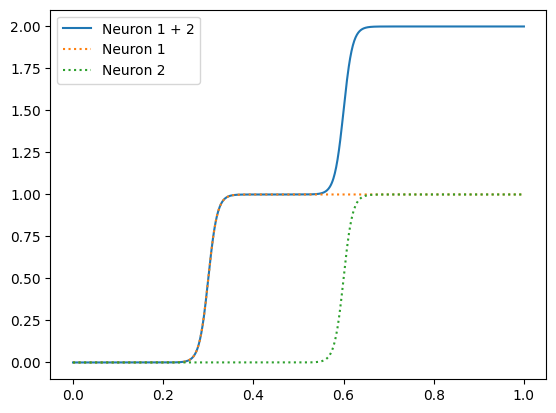

In [40]:
w = 100

s1 = 0.3
s2 = 0.6

a1 = sigmoid(w*(x - s1))
a2 = sigmoid(w*(x - s2))

y = a1 + a2

plt.plot(x, y, label = 'Neuron 1 + 2')
plt.plot(x, a1, linestyle = ':', label = 'Neuron 1')
plt.plot(x, a2, linestyle = ':', label = 'Neuron 2')
plt.legend()

Again, play around! What kind of funky functions can you create?

In [61]:
@interact(w1=(-100,100.0,0.1),
          w2=(-100,100.0,0.1),
          s1=(0.0,1.0,0.1),
          s2=(0.0,1.0,0.1))

def neuron(w1=10, w2=-10, s1=0.3, s2=0.6):

    a1 = sigmoid(w1*(x - s1))
    a2 = sigmoid(w2*(x - s2))
    y = a1 + a2 

    plt.plot(x, y, label = 'Neuron 1 + 2')
    plt.plot(x, a1, linestyle = ':', label = 'Neuron 1')
    plt.plot(x, a2, linestyle = ':', label = 'Neuron 2')
    plt.legend()

interactive(children=(FloatSlider(value=10.0, description='w1', min=-100.0), FloatSlider(value=-10.0, descript…

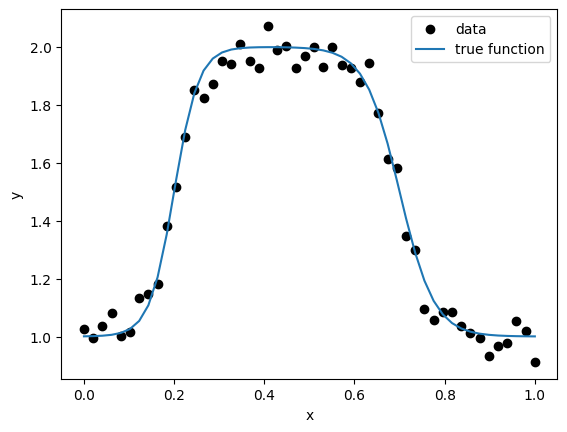

In [72]:
np.random.seed(42)

xdata = np.linspace(0,1,50)

# True parameters
w1_true = 37
w2_true = -26
s1_true = 0.2
s2_true = 0.7

ytrue = (
    sigmoid(w1_true*(xdata-s1_true))
    + sigmoid(w2_true*(xdata-s2_true))
)

ydata = ytrue + np.random.normal(0,0.05,len(xdata))

plt.scatter(xdata, ydata, color='k', label="data")
plt.plot(xdata, ytrue, label="true function")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
# MODEL
def network(x, w1, w2, s1, s2):

    a1 = sigmoid(w1*(x-s1))
    a2 = sigmoid(w2*(x-s2))

    return a1 + a2

# LOSS FUNCTION 
def loss(ytrue, ypred):
    return np.mean((ytrue - ypred)**2)

# INITIAL GUESS
w1 = 30
w2 = -10
s1 = 0.4
s2 = 0.6

# GRADIENT DESCENT 
lr = 0.01   
eps = 1e-5  # a tiny step to take when we are deriving this numerically.

losses = []

for i in range(100):

    ypred = network(xdata, w1, w2, s1, s2)
    L = loss(ydata, ypred)

    losses.append(L)

    # finite difference derivatives
    dw1 = (loss(ydata, network(xdata,w1+eps,w2,s1,s2))- L) / eps

    dw2 = (loss(ydata, network(xdata,w1,w2+eps,s1,s2))- L) / eps

    ds1 = (loss(ydata, network(xdata,w1,w2,s1+eps,s2))- L) / eps

    ds2 = (loss(ydata, network(xdata,w1,w2,s1,s2+eps)) - L) / eps

    # gradient descent step
    w1 -= lr * dw1
    w2 -= lr * dw2
    s1 -= lr * ds1
    s2 -= lr * ds2

Text(0, 0.5, 'Loss')

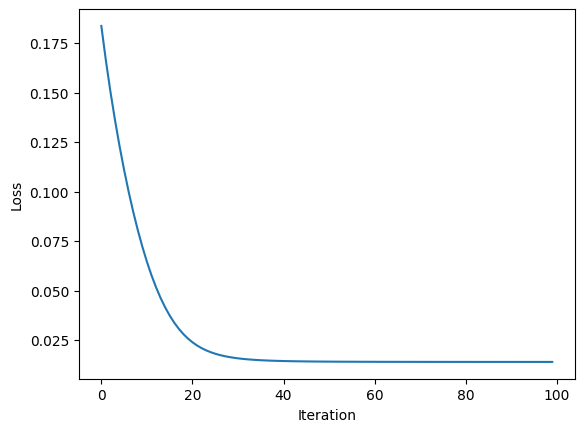

In [119]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
#plt.yscale("log")

29.99991674676839 -10.003054098916499 0.1999306084758359 0.6936119818448047


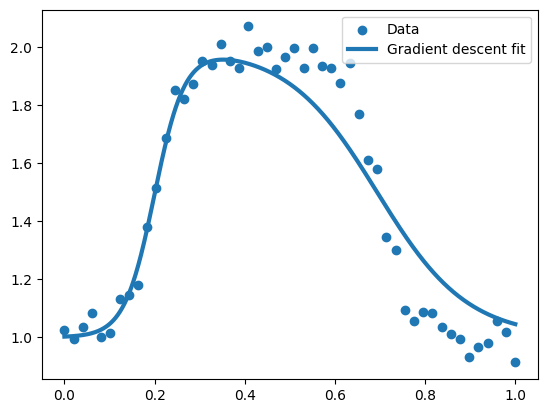

In [120]:
print(w1, w2, s1, s2)
xfine = np.linspace(0,1,1000)

plt.scatter(xdata, ydata, label="Data")

plt.plot(
    xfine,
    network(xfine,w1,w2,s1,s2),
    linewidth=3,
    label="Gradient descent fit"
)

plt.legend()

# Q: After playing around with "hyperparameters" like the learning rate and initial guess, can you get a good fit? 
# Q: Sometimes, the loss will flatten out, but we will still see a bad fit. Why might this happen?

Real neural networks almost never use finite differences because they are very slow. For four parameters, we needed four evaluations. This will get very expensive very quickly. Modern NNs instead use backpropagation, which more efficiently compute gradients.